## Does performance vary by surface FOR THE SAME PLAYERS?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"

event = pd.read_parquet(f'{IN_DIR}/event.parquet')
home = pd.read_parquet(f'{IN_DIR}/home_team.parquet')
away = pd.read_parquet(f'{IN_DIR}/away_team.parquet')
tourn = pd.read_parquet(f'{IN_DIR}/tournament.parquet')

In [2]:
family_map = {'Hardcourt outdoor': 'Hard', 'Hardcourt indoor': 'Hard', 'Red clay': 'Clay',
              'Red clay indoor': 'Clay', 'Green clay': 'Clay', 'Grass': 'Grass',
              'Carpet indoor': 'Carpet', 'Synthetic outdoor': 'Synthetic'}
tourn['surface_family'] = tourn['ground_type'].map(family_map)

In [3]:
completed = event.loc[(event['match_completed'] == True) & (event['score_ready']== True), ['match_id', 'winner_code']]
h = home[['match_id', 'player_id']].merge(completed, on='match_id').merge(tourn[['match_id', 'surface_family']], on='match_id')
h['won'] = h['winner_code'] == 1
a = away[['match_id', 'player_id']].merge(completed, on='match_id').merge(tourn[['match_id', 'surface_family']], on='match_id')
a['won'] = a['winner_code'] == 2
played = pd.concat([h[['player_id', 'surface_family', 'won']], a[['player_id', 'surface_family', 'won']]]).dropna(subset=['surface_family'])

In [4]:
agg = played.groupby(['player_id', 'surface_family']).agg(matches=('won', 'size'), win_rate=('won', 'mean')).reset_index()
piv = agg.pivot(index='player_id', columns='surface_family', values=['matches', 'win_rate'])

In [5]:
piv

matches                            win_rate                  \
surface_family  Carpet Clay Grass  Hard Synthetic   Carpet      Clay Grass   
player_id                                                                    
14414              NaN  6.0   NaN  10.0       NaN      NaN  0.500000   NaN   
14548              NaN  3.0   NaN   1.0       NaN      NaN  0.333333   NaN   
14844              NaN  NaN   NaN  14.0       NaN      NaN       NaN   NaN   
14882              NaN  NaN   NaN   2.0       NaN      NaN       NaN   NaN   
15126              NaN  NaN   NaN   7.0       NaN      NaN       NaN   NaN   
...                ...  ...   ...   ...       ...      ...       ...   ...   
488404             NaN  4.0   NaN   4.0       NaN      NaN  0.500000   NaN   
489714             NaN  NaN   NaN   1.0       NaN      NaN       NaN   NaN   
490732             NaN  5.0   NaN   NaN       NaN      NaN  0.800000   NaN   
499834             NaN  2.0   NaN   NaN       NaN      NaN  0.500000   NaN   
509586             NaN  1.0   NaN   NaN       NaN      NaN  0.000000   NaN   

                                    
surface_family      Hard Synthetic  
player_id                           
14414           0.600000       NaN  
14548           0.000000       NaN  
14844           0.642857       NaN  
14882           0.500000       NaN  
15126           0.571429       NaN  
...                  ...       ...  
488404          0.750000       NaN  
489714          0.000000       NaN  
490732               NaN       NaN  
499834               NaN       NaN  
509586               NaN       NaN  

[2591 rows x 10 columns]

In [6]:
MIN_MATCHES = 5
mask = (piv[('matches', 'Hard')] >= MIN_MATCHES) & (piv[('matches', 'Clay')] >= MIN_MATCHES)
paired = piv[mask].copy()
paired.columns = ['_'.join(c) for c in paired.columns]
paired = paired[['win_rate_Hard', 'win_rate_Clay']].dropna()
paired['diff'] = paired['win_rate_Clay'] - paired['win_rate_Hard']

In [7]:
print(f"n = {len(paired)} players with >= {MIN_MATCHES} matches on BOTH Hard and Clay")
print(f"Mean within-player difference (Clay - Hard win rate): {paired['diff'].mean():+.1%}")
print(f"Players better on Clay: {(paired['diff'] > 0).sum()} | better on Hard: {(paired['diff'] < 0).sum()} | tied: {(paired['diff'] == 0).sum()}")
from scipy import stats
tstat, pval = stats.ttest_rel(paired['win_rate_Clay'], paired['win_rate_Hard'])
print(f"Paired t-test: t={tstat:.2f}, p={pval:.3f}")

n = 96 players with >= 5 matches on BOTH Hard and Clay
Mean within-player difference (Clay - Hard win rate): +6.8%
Players better on Clay: 55 | better on Hard: 36 | tied: 5
Paired t-test: t=2.94, p=0.004


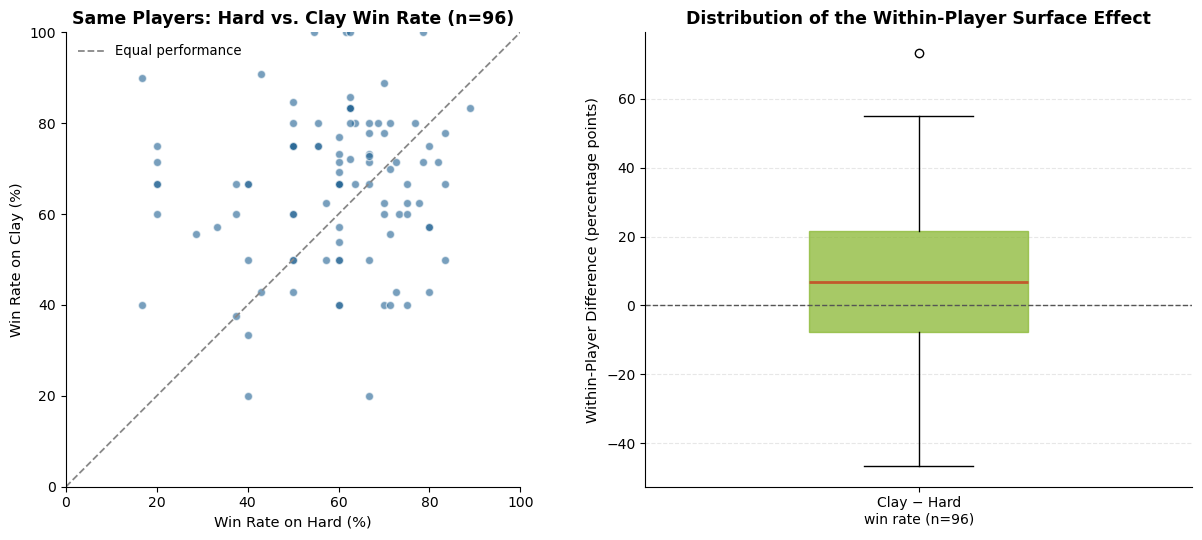

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
 
ax = axes[0]
ax.scatter(paired['win_rate_Hard'] * 100, paired['win_rate_Clay'] * 100, s=35, color='#1E6091', alpha=0.6, edgecolor='white')
lims = [0, 100]
ax.plot(lims, lims, color='#888888', linestyle='--', linewidth=1.3, label='Equal performance')
ax.set_xlabel('Win Rate on Hard (%)', fontsize=10.5)
ax.set_ylabel('Win Rate on Clay (%)', fontsize=10.5)
ax.set_title(f'Same Players: Hard vs. Clay Win Rate (n={len(paired)})', fontsize=12.5, fontweight='bold')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9.5)
ax.set_aspect('equal')
 
ax = axes[1]
bp = ax.boxplot([paired['diff'] * 100], tick_labels=[f'Clay − Hard\nwin rate (n={len(paired)})'],
                 patch_artist=True, showfliers=True, widths=0.4,
                 medianprops=dict(color='#C1592C', linewidth=2))
bp['boxes'][0].set_facecolor('#8AB833'); bp['boxes'][0].set_alpha(0.75); bp['boxes'][0].set_edgecolor('#8AB833')
ax.axhline(0, color='#555555', linestyle='--', linewidth=1)
ax.set_ylabel('Within-Player Difference (percentage points)', fontsize=10.5)
ax.set_title('Distribution of the Within-Player Surface Effect', fontsize=12.5, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
 
plt.tight_layout()
plt.savefig('charts\surface_within_player.png', dpi=200, bbox_inches='tight')

Observation: Among 96 players with ≥5 matches on both surfaces, mean within-player difference (Clay − Hard) is +6.8 pp (55 better on Clay, 36 on Hard, 5 tied). Paired t-test: t = 2.94, p = 0.004.

What the test does: Each player is their own control. The test asks whether the average of (Clay rate − Hard rate) differs from zero across these 96 players.
t and p. t = 2.94 means the mean difference is about 2.94 standard errors from zero. p = 0.004 is the chance of a result this extreme if the true mean difference were zero — below 0.05, so the null is rejected.

What it does not say: p is not effect size. +6.8 pp is modest; individual differences spread widely, so the mean does not describe most players well. A large outlier argues for a Wilcoxon check as robustness.

Limitation: Shows an average shift, not a cause (surface physics, schedule, fatigue, etc. are not identified here).

نمودار چپ (scatter)

هر نقطه یک بازیکن است. خط چین یعنی نرخ برد برابر روی دو سطح. نقطه بالای خط یعنی روی خاکی بهتر از هارد همان بازیکن؛ زیر خط برعکس. پراکندگی حول خط نشان می‌دهد برای بخشی از بازیکن‌ها سطح مهم است و برای بخشی نه.

نمودار راست (boxplot اختلاف)

توزیع همان تفاوت (بر حسب درصد) است. اگر میانه و جعبه حول صفر باشند، اثر سطح به‌طور متوسط نزدیک صفر است؛ اگر جعبه عمدتاً بالای صفر باشد، برای این نمونه به‌طور متوسط خاکی نسبت به هارد همان بازیکن نرخ برد بالاتری داشته.

نتیجه به آستانهٔ حداقل مسابقه روی هر سطح، و به ترکیب تورنمنت‌های دیتاست وابسته است.
وابستگی مسابقات یک بازیکن و تفاوت سطح تورنمنت‌ها در مدل سادهٔ t وارد نشده؛ پس t یک آزمون اولیه روی میانگین اختلاف است، نه مدل علّی کامل.